# 3 Data analysis

## Setup

### Load libraries

In [2]:
library(tidyverse)
library(plotrix)
library(RColorBrewer)
library(Hmisc)
library(patchwork)
library(tools)
library(svglite)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




### Define working directory and path to CSV

In [ ]:
# Define working directory and path to CSV
wd <- "/path/to/03_axenic_xenic_growth/"
path <- file.path(wd, "02_data", "tables", "quant_cells.csv")

# Load data
data.raw <- read.csv(path, header = TRUE, check.names = TRUE, sep = ",")

### Define image scaling

In [1]:
# Define physical scaling
pixels <- 2048
physical_length_in_uM <- 328.1164

# Convert to µm/pixel and µm²/pixel
scale_factor <- physical_length_in_uM / pixels
pixel_area <- scale_factor^2


### Calculate field area

In [15]:
# Define physical field size (µm)
physical_length_in_uM <- 328.1164

# Convert to field area in mm²
field_area_um2 <- physical_length_in_uM^2
field_area_mm2 <- field_area_um2 / 1e6  # µm² to mm²

### Color palettes

In [14]:
# Define color palettes
wt_colors <- brewer.pal(n = 9, name = "Greens")
ko_colors <- brewer.pal(n = 9, name = "Purples")
re_colors <- brewer.pal(n = 9, name = "Blues")

# Pick light and dark shades for consistency
light <- 5
dark <- 7

# Color mappings by strain
color_map_light <- c("wt" = wt_colors[light], "ko" = ko_colors[light], "re" = re_colors[light])
color_map_dark  <- c("wt" = wt_colors[dark],  "ko" = ko_colors[dark],  "re" = re_colors[dark])

### Labels

In [ ]:
# Expressions for proper formatting in plot legends
strain_rename <- c(
  "ko" = expression(italic(disfp)^"–" * " mutant"),
  "re" = expression(italic(disfp)^"–" * " rescue"), 
  "wt" = expression("Ax2 wildtype")
)

## Prepare data

## Initial cleanup and column extraction

In [5]:
# Copy raw data for processing
data.cleanup <- data.raw

# Extract cultivation condition from file path
data.cleanup$cultivation <- basename(dirname(data.cleanup$filename))

# Extract filename only (remove full path)
data.cleanup$filename <- basename(data.cleanup$filename)

# Separate metadata from filename
data.cleanup <- data.cleanup %>%
  separate(filename, into = c("experiment", "strain", "well", "region", "time", "z"), sep = "_", remove = TRUE)


Warning message:
“Expected 6 pieces. Additional pieces discarded in 1547952 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


### Clean and calculate basic metrics

In [6]:
# Keep unfiltered version
data.unfiltered <- data.cleanup

# Convert time info to hours (frame number * 4)
data.unfiltered$time <- as.integer(gsub("[^0-9]", "", data.unfiltered$time)) * 4

# Calculate equivalent diameter from area
data.unfiltered <- data.unfiltered %>%
  mutate(equivalent_diameter = sqrt(4 * area / pi))

# Calculate circularity (exclude perimeter = 0)
data.unfiltered <- data.unfiltered %>%
  mutate(circularity = ifelse(perimeter > 0, 4 * pi * area / (perimeter^2), NA))

### Filter small objects and apply strain-specific exclusion

In [7]:
# Filter: keep objects ≥ 5 µm diameter (after scaling)
data <- data.unfiltered %>%
  filter(equivalent_diameter * scale_factor >= 5)

# Filter: exclude specific wells for wildtype
data <- data %>%
  filter(
    (strain == "wt" & !well %in% c("w1", "w5")) |
    (strain != "wt")
  )

## Analysis

### Region-level summary

In [9]:
# Summarize per region
data.summary.region <- data %>%
  group_by(experiment, cultivation, strain, well, region, time) %>%
  summarise(
    n.region = n(),
    area.region.mean = mean(area), 
    circularity.region.mean = mean(circularity),                       
    perimeter.region.mean = mean(perimeter),                       
    eccentricity.region.mean = mean(eccentricity), 
    orientation.region.mean = mean(orientation),
    .groups = "drop"
  )

# Normalize cell count relative to time 0 per region
data.summary.region <- data.summary.region %>%
  group_by(experiment, cultivation, strain, well, region) %>%
  mutate(Nt_N0.region = n.region / n.region[time == 0])


### Experiment-level summary

In [10]:
# Summarize across regions within each experiment
data.summary.experiment <- data.summary.region %>%
  group_by(experiment, cultivation, strain, well, time) %>%
  summarise(
    n.experiment.mean = mean(n.region),
    Nt_N0.experiment.mean = mean(Nt_N0.region),
    area.experiment.mean = mean(area.region.mean), 
    circularity.experiment.mean = mean(circularity.region.mean),                       
    perimeter.experiment.mean = mean(perimeter.region.mean),                       
    eccentricity.experiment.mean = mean(eccentricity.region.mean), 
    orientation.experiment.mean = mean(orientation.region.mean),
    .groups = "drop"
  )

# Normalize across time per experiment
data.summary.experiment <- data.summary.experiment %>%
  group_by(experiment, cultivation, strain, well) %>%
  mutate(Nt_N0.experiment = n.experiment.mean / n.experiment.mean[time == 0])


###  Strain-level summary (with SEs)

In [11]:
# Strain-level summary with standard errors
data.summary.strain <- data.summary.experiment %>%
  group_by(cultivation, strain, time) %>%
  summarise(
    n.mean = mean(n.experiment.mean), 
    n.mean.se = std.error(n.experiment.mean),           

    Nt_N0.mean = mean(Nt_N0.experiment), 
    Nt_N0.mean.se = std.error(Nt_N0.experiment),       

    Nt_N0.region.mean = mean(Nt_N0.experiment.mean), 
    Nt_N0.region.mean.se = std.error(Nt_N0.experiment.mean),    

    area.mean = mean(area.experiment.mean),                       
    area.mean.se = std.error(area.experiment.mean), 

    circularity.mean = mean(circularity.experiment.mean), 
    circularity.mean.se = std.error(circularity.experiment.mean),

    perimeter.mean = mean(perimeter.experiment.mean),                       
    perimeter.mean.se = std.error(perimeter.experiment.mean), 

    eccentricity.mean = mean(eccentricity.experiment.mean),                       
    eccentricity.mean.se = std.error(eccentricity.experiment.mean), 

    orientation.mean = mean(orientation.experiment.mean),                       
    orientation.mean.se = std.error(orientation.experiment.mean), 
    .groups = "drop"
  )


## Visualization

### Set notebook display size, factor order, and time windows

In [ ]:
# Set default plot size for inline display
options(repr.plot.width = 10, repr.plot.height = 4)

# Set consistent factor level order for plotting
strain_levels <- c("wt", "ko", "re")
data.summary.strain <- data.summary.strain %>%
  mutate(strain = factor(strain, levels = strain_levels))

# Optional thresholds for cutting time windows in plots
t_threshold_axenic <- 96
t_threshold_xenic  <- 48

###  Define custom themes for plotting

In [ ]:
# Theme without legend (used for inline or combined plots)
custom_theme <- theme_minimal(base_size = 8) +
  theme(
    axis.title = element_text(face = "bold", size = 8),
    axis.text = element_text(size = 8, color = "black"),
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "grey75", size = 0.15),
    axis.line.x = element_line(color = "black", size = 0.25),
    axis.ticks.x = element_line(color = "black", size = 0.25),
    axis.ticks.y = element_blank(),
    strip.text = element_blank(),
    strip.background = element_rect(colour = "white", fill = "white"),
    legend.position = "none"
  )

# Variant with compact legend (used on one panel only)
custom_theme2 <- custom_theme +
  theme(
    legend.title = element_blank(),
    legend.spacing.y = unit(0.1, "pt"),
    legend.key.size = unit(0.15, "cm"),
    legend.position = c(1.05, 0.05),
    legend.justification = c(1, 0)
  )


### Create plot for xenic condition

In [ ]:
# Plot growth over time in xenic cultivation
p_xenix <- data.summary.strain %>%
  filter(cultivation == "xenic") %>%
  ggplot(aes(x = time, y = n.mean / field_area_mm2, group = strain, colour = strain)) +
  facet_wrap(~cultivation, scale = "free") +
  geom_ribbon(aes(
    ymin = (n.mean - n.mean.se) / field_area_mm2,
    ymax = (n.mean + n.mean.se) / field_area_mm2,
    fill = strain
  ), alpha = 0.2, size = 0) +
  geom_line(size = 0.5) +
  scale_fill_manual(values = color_map_light, labels = strain_rename) +
  scale_color_manual(values = color_map_dark, labels = strain_rename) +
  scale_y_continuous(breaks = seq(0, max(data.summary.strain$n.mean / field_area_mm2, na.rm = TRUE), by = 1000)) +
  labs(y = "cells per mm²", x = "time in h") +
  theme_minimal(base_size = 14, base_family = "Helvetica") +
  theme(
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.75),
    axis.ticks.x = element_line(color = "black", size = 0.25),
    axis.ticks.y = element_blank(),
    strip.text = element_blank(),
    strip.background = element_rect(fill = "white", colour = "white"),
    legend.position = "none"
  ) +
  coord_cartesian(xlim = c(0, 36)) +
  custom_theme


### Create plot for axenic condition

In [ ]:
# Plot growth over time in axenic cultivation
p_axenix <- data.summary.strain %>%
  filter(cultivation == "axenic") %>%
  ggplot(aes(x = time, y = n.mean / field_area_mm2, group = strain, colour = strain)) +
  facet_wrap(~cultivation, scale = "free") +
  geom_ribbon(aes(
    ymin = (n.mean - n.mean.se) / field_area_mm2,
    ymax = (n.mean + n.mean.se) / field_area_mm2,
    fill = strain
  ), alpha = 0.2, size = 0) +
  geom_line(size = 0.5) +
  scale_fill_manual(values = color_map_light, labels = strain_rename) +
  scale_color_manual(values = color_map_dark, labels = strain_rename) +
  scale_y_continuous(breaks = seq(0, max(data.summary.strain$n.mean / field_area_mm2, na.rm = TRUE), by = 2000)) +
  labs(y = "", x = "time in h") +
  theme_minimal(base_size = 14, base_family = "Helvetica") +
  theme(
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.75),
    axis.ticks.x = element_line(color = "black", size = 0.25),
    axis.ticks.y = element_blank(),
    strip.text = element_blank(),
    strip.background = element_rect(fill = "white", colour = "white"),
    legend.position = "none"
  ) +
  coord_cartesian(xlim = c(0, 96)) +
  custom_theme2


### Combine and export plot

✔ Created directory: /Net/Groups/pbtdata/07_DD/06_PPT/05_analysis/03_image_analysis/03_axenic_xenic_growth/03_results/img.



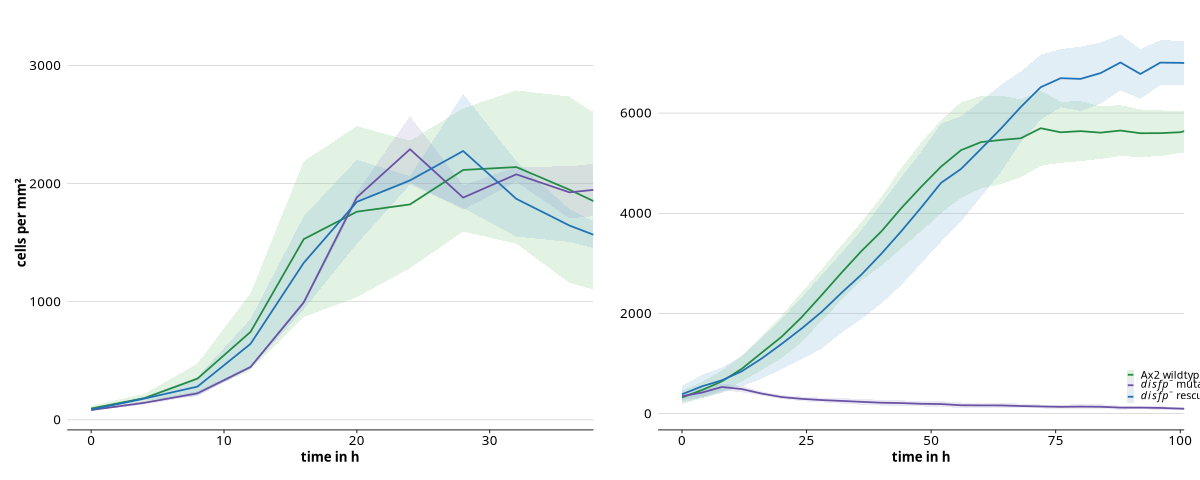

In [ ]:
# Combine xenic and axenic plots using patchwork
plot_growth_curve <- (p_xenix + p_axenix) +
  plot_layout() & theme(
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    legend.background = element_rect(fill = "transparent", color = NA),
    legend.key = element_rect(fill = "transparent", color = NA)
  )

# Define path and save as SVG with transparent background
save_path <- file.path(wd, "03_results", "img", "plot_growth_curve_transparent.svg")
ggsave(
  filename = save_path,
  plot = plot_growth_curve,
  create.dir = TRUE,
  width = 87 / 25.4,
  height = 38.5 / 25.4,
  units = "in",
  bg = "transparent",
  device = svglite
)

# Display the combined plot
plot_growth_curve